Student Name: Dibyanshu Ratna Bajracharya

Student ID: 2408571

# Part III – Sentiment Classification with RNN / LSTM
## 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

This section covers loading the raw hotel review data, scrubbing the text, exploring the vocabulary visually,
partitioning the data into training and test sets, encoding reviews as integer sequences with Keras, and applying 90th-percentile-based padding to ensure uniform sequence length across all samples.

## Section 1 – Install Dependencies & Mount Drive

The `contractions` package is installed to expand shortened word forms (e.g. *can't → cannot*).
Google Drive is then mounted so the dataset file can be read directly from shared storage.

In [3]:
!pip install contractions

  Using cached contractions-0.1.73-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached textsearch-0.0.24-py2.py3-none-any.whl.metadata (1.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.4 MB/s eta 0:00:00


## Section 2 – Imports

In [4]:
import time
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [5]:
np.random.seed(42)
random.seed(42)

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 3 – Dataset Path

In [65]:
data_path = "/content/drive/MyDrive/AI/2. Hotel Review Dataset/Hotel_Reviews.csv"

## Section 4 – Utility Functions

Several reusable utility functions are defined here for visualising model performance: one for learning curves and another for confusion matrix heatmaps.

In [8]:
def display_learning_curves(history, title_prefix="Model"):
    """
    Plots accuracy and loss curves side-by-side for a Keras history object.
    Matches the Part 2 style exactly.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    epoch_range = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    ax1.plot(epoch_range, history.history['accuracy'],     label='Training Accuracy',   color='skyblue', marker='o')
    ax1.plot(epoch_range, history.history['val_accuracy'], label='Validation Accuracy',  color='salmon', marker='s')
    ax1.set_title(f"{title_prefix} – Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(epoch_range, history.history['loss'],     label='Training Loss',   color='skyblue', marker='o')
    ax2.plot(epoch_range, history.history['val_loss'], label='Validation Loss', color='salmon', marker='s')
    ax2.set_title(f"{title_prefix} – Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [9]:
def render_confusion_heatmap(y_true, y_pred, class_labels, title="Confusion Matrix", cmap_name="YlGnBu"):
    """
    Generates a colour-coded confusion matrix heatmap using seaborn.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap_name,
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [10]:
def evaluate_model(model, test_padded, test_labels, label="Model", cmap_name="YlGnBu"):
    """
    Runs inference, prints classification report, plots confusion matrix.
    Returns y_pred array and accuracy score.
    """
    prediction_probs   = model.predict(test_padded, verbose=1)
    predicted_classes = np.argmax(prediction_probs, axis=1)

    eval_report = classification_report(
        test_labels, predicted_classes,
        target_names=SENTIMENT_CLASSES, output_dict=True
    )
    eval_accuracy = eval_report['accuracy'] # Changed from 'eval_accuracy' to 'accuracy'

    print(f"\n{'='*50}")
    print(f"  Classification Report — {label}")
    print(f"{'='*50}")
    print(classification_report(
        test_labels, predicted_classes,
        target_names=SENTIMENT_CLASSES
    ))

    render_confusion_heatmap(
        test_labels, predicted_classes,
        class_labels=SENTIMENT_CLASSES,
        title=f"Confusion Matrix — {label}",
        cmap_name=cmap_name
    )
    return predicted_classes, eval_accuracy

# Step 1 – Load the Dataset

The CSV is read into a Pandas DataFrame with `ISO-8859-1` encoding to handle special characters. The overall dimensions and a brief sample of the data are then displayed.

In [11]:
data = pd.read_csv(data_path, encoding="ISO-8859-1")
print("Data dimensions:", data.shape)
data.head()

Data dimensions: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [12]:
print("Score breakdown:")
print(data['Rating'].value_counts().sort_index())
print("\nMissing entries:")
print(data.isnull().sum())
print("\nColumn overview:")
data.info()

Score breakdown:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

Missing entries:
Review    0
Rating    0
dtype: int64

Column overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [13]:
data = data[['Review', 'Rating']]
data.dropna(inplace=True)
print("Dimensions after removing empty rows:", data.shape)
data.head()

Dimensions after removing empty rows: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


# Step 2 – Text Cleaning

Each review passes through a sequential cleaning pipeline that carries out the following operations:
1. Convert all characters to lowercase
2. Expand contracted word forms (e.g. *won't → will not*)
3. Strip out any URLs found in the text
4. Remove `@mentions` and `#hashtag` patterns
5. Delete all numeric characters
6. Discard punctuation and non-alphabetic symbols
7. Normalise whitespace by collapsing multiple spaces

Following this sanitisation pass, common English stopwords are filtered out and every remaining token is reduced to its base lemma form.

In [14]:
nltk.download('stopwords')
nltk.download('wordnet')

stopword_set = set(stopwords.words('english'))
word_lemmatizer = WordNetLemmatizer()

def sanitize_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def prepare_text(text):
    text   = sanitize_text(text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stopword_set]
    tokens = [word_lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

print("Processing reviews — please wait...")
data['processed_text'] = data['Review'].apply(prepare_text)
print("Text preparation complete.")
data[['Review', 'processed_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Processing reviews — please wait...
Text preparation complete.


,Review,processed_text
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


# Step 3 – Visualise Cleaned Data

### 3.1 Word Cloud

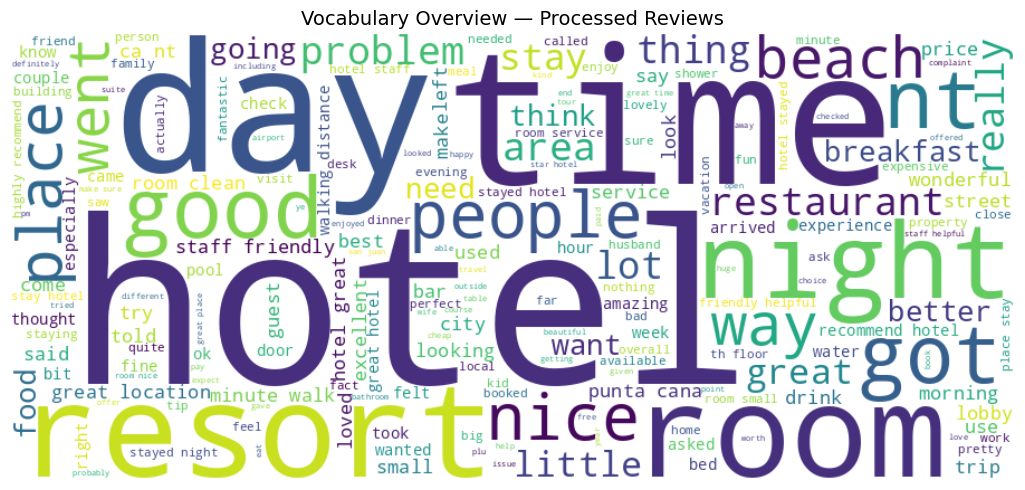

In [15]:
text = " ".join(data['processed_text'])

wordcloud = WordCloud(width=900, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Vocabulary Overview — Processed Reviews", fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Top 20 Most Frequent Words

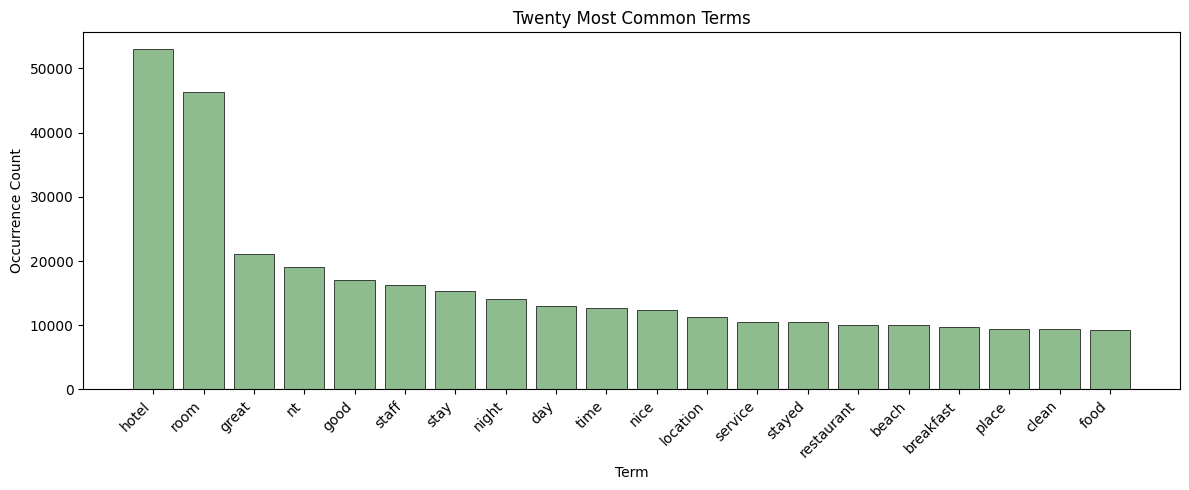

In [16]:
word_tokens    = text.split()
top_word_pairs = Counter(word_tokens).most_common(20)
freq_words, freq_counts = zip(*top_word_pairs)

plt.figure(figsize=(12, 5))
plt.bar(freq_words, freq_counts, color='darkseagreen', edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.title("Twenty Most Common Terms")
plt.xlabel("Term")
plt.ylabel("Occurrence Count")
plt.tight_layout()
plt.show()

# Step 4 – Label Encoding & Train / Test Split (80 / 20)

Star ratings on the 1–5 scale are mapped onto three discrete sentiment categories:
- **0 – Negative** – reviews with a score of 2 or below
- **1 – Neutral** – reviews with a score of exactly 3
- **2 – Positive** – reviews with a score of 4 or higher

The labelled data is then partitioned into an 80 % training set and a 20 % held-out test set, using `random_state=42` for reproducibility.

In [54]:
def map_rating_to_label(r):
    if r <= 2:
        return 0   # Negative
    elif r == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

data['sentiment'] = data['Rating'].apply(map_rating_to_label)

X = data['processed_text']
y = data['sentiment']
class_count = 3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test  size: {len(X_test)}")

Train size: 16392
Test  size: 4099


### 4.1 Sentiment Class Distribution

A bar chart and pie chart are produced to reveal the imbalance across sentiment classes, which motivates the use of `class_weight='balanced'` so the minority classes receive proportionally higher loss penalties during training.

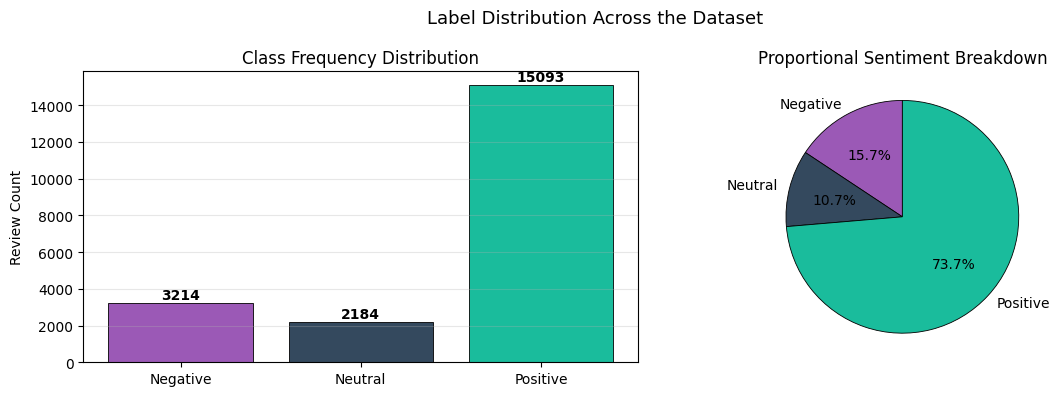

In [18]:
sentiment_label_map       = {0: "Negative", 1: "Neutral", 2: "Positive"}
class_counts  = data['sentiment'].value_counts().sort_index()
class_labels_list            = [sentiment_label_map[i] for i in class_counts.index]
palette            = ['#9b59b6', '#34495e', '#1abc9c'] # New palette for bar and pie charts

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bar_patches = ax1.bar(class_labels_list, class_counts.values, color=palette, edgecolor='black', linewidth=0.6)
ax1.set_title("Class Frequency Distribution")
ax1.set_ylabel("Review Count")
ax1.grid(axis='y', alpha=0.3)
for bar, count in zip(bar_patches, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
ax2.pie(class_counts.values, labels=class_labels_list, colors=palette,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='black', linewidth=0.6))
ax2.set_title("Proportional Sentiment Breakdown")

plt.suptitle("Label Distribution Across the Dataset", fontsize=13)
plt.tight_layout()
plt.show()

# Step 5 – Keras Tokenisation

Keras `Tokenizer` is fitted on the training corpus to construct a vocabulary limited to the `vocabulary_size = 5000` most frequent terms. Each review is then encoded as a list of integer indices corresponding to those vocabulary entries. Any word absent from the vocabulary is mapped to the reserved `<OOV>` (out-of-vocabulary) token.

In [19]:
vocabulary_size = 5000

text_tokenizer = Tokenizer(num_words=vocabulary_size, oov_token="<OOV>")
text_tokenizer.fit_on_texts(X_train)

train_sequences = text_tokenizer.texts_to_sequences(X_train)
test_sequences  = text_tokenizer.texts_to_sequences(X_test)
print('Preview of tokenised sequence:', train_sequences[0][:10], '...')

Preview of tokenised sequence: [592, 1052, 128, 13, 156, 8, 240, 13, 451, 3390] ...


# Step 6 – Percentile-Based Padding

Instead of padding every sequence to the length of the longest review, the **90th percentile** of training sequence lengths is used as the target length (`sequence_length`). This strategy avoids excessive padding caused by unusually long outlier reviews, retaining the vast majority of informational content. All shorter sequences are zero-padded at the trailing end (`padding='post'`).

In [20]:
seq_lengths = [len(seq) for seq in train_sequences]
sequence_length = int(np.percentile(seq_lengths, 90))
print(f"90th-percentile sequence length (sequence_length): {sequence_length}")

train_padded = pad_sequences(train_sequences, maxlen=sequence_length, padding='post')
test_padded  = pad_sequences(test_sequences,  maxlen=sequence_length, padding='post')

print("Padded training set shape:", train_padded.shape)
print("Padded test set shape:", test_padded.shape)

90th-percentile sequence length (sequence_length): 189
Padded training set shape: (16392, 189)
Padded test set shape: (4099, 189)


# Step 7 – Class Weights

The hotel review dataset exhibits a strong positive-rating bias, meaning most samples belong to the Positive class.
Calling `compute_class_weight('balanced')` automatically scales the per-class loss contribution so that underrepresented classes — Negative and Neutral — receive greater penalty, discouraging the model from defaulting to the majority class.

In [21]:
train_labels = y_train.values.flatten()
test_labels  = y_test.values.flatten()

label_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
label_weights = dict(enumerate(label_weights))
print("Computed label weights:", label_weights)

Computed label weights: {0: np.float64(2.1104673619157976), 1: np.float64(3.1187214611872145), 2: np.float64(0.4534063563189777)}


# Step 8 – Shared Settings

In [22]:
embed_size = 100

early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

SENTIMENT_CLASSES = ["Negative", "Neutral", "Positive"]

---
# Model 1 – Simple RNN

This serves as a minimal reference model built from three components:
- `Embedding(vocabulary_size, embed_size)` — a learnable word-vector lookup table trained from scratch.
- `SimpleRNN(64)` — a recurrent layer that steps through tokens one at a time.
- `Dense(32, relu)` → `Dense(3, softmax)` — a two-layer classification head outputting class probabilities.

While computationally inexpensive, Simple RNNs are susceptible to the **vanishing gradient** phenomenon, which limits their ability to capture dependencies across long input sequences.

In [23]:
rnn_model = Sequential([
    Input(shape=(sequence_length,)),
    Embedding(input_dim=vocabulary_size, output_dim=embed_size, input_length=sequence_length),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(class_count, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 189, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,739 (1.96 MB)

 Trainable params: 512,739 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model 1 – Simple RNN

In [24]:
rnn_t_start = time.time()

rnn_history = rnn_model.fit(
    train_padded, train_labels,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopper],
    class_weight=label_weights
)

rnn_t_end = time.time()
rnn_elapsed = rnn_t_end - rnn_t_start
print(f"Training time: {rnn_elapsed:.2f} sec")

Epoch 1/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.3743 - loss: 1.1096 - val_accuracy: 0.2595 - val_loss: 1.1199
Epoch 2/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.3502 - loss: 1.1033 - val_accuracy: 0.2906 - val_loss: 1.1610
Epoch 3/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3625 - loss: 1.0961 - val_accuracy: 0.1351 - val_loss: 1.3527
Epoch 4/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3191 - loss: 1.1111 - val_accuracy: 0.3041 - val_loss: 1.1368
Epoch 5/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3369 - loss: 1.1046 - val_accuracy: 0.3095 - val_loss: 1.1046
Epoch 6/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4117 - loss: 1.0998 - val_accuracy: 0.4974 - val_loss: 1.0358
Epoch 7/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4981 - loss: 1.0870 - val_accuracy: 0.4873 - val_loss: 1.0475
Epoch 8/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5003 - loss: 1.0852 - val_ac

## Model 1 – Training Curves

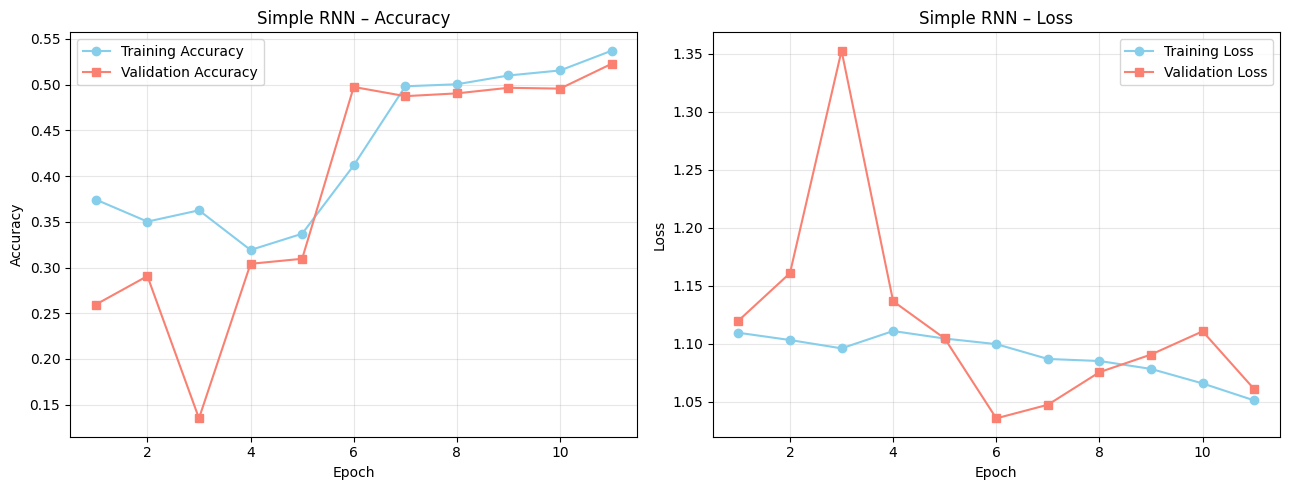

In [25]:
display_learning_curves(rnn_history, title_prefix="Simple RNN")

## Evaluate Model 1 – Simple RNN

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

  Classification Report — Simple RNN
              precision    recall  f1-score   support

    Negative       0.22      0.10      0.14       625
     Neutral       0.14      0.56      0.22       432
    Positive       0.82      0.56      0.66      3042

    accuracy                           0.49      4099
   macro avg       0.39      0.41      0.34      4099
weighted avg       0.66      0.49      0.54      4099



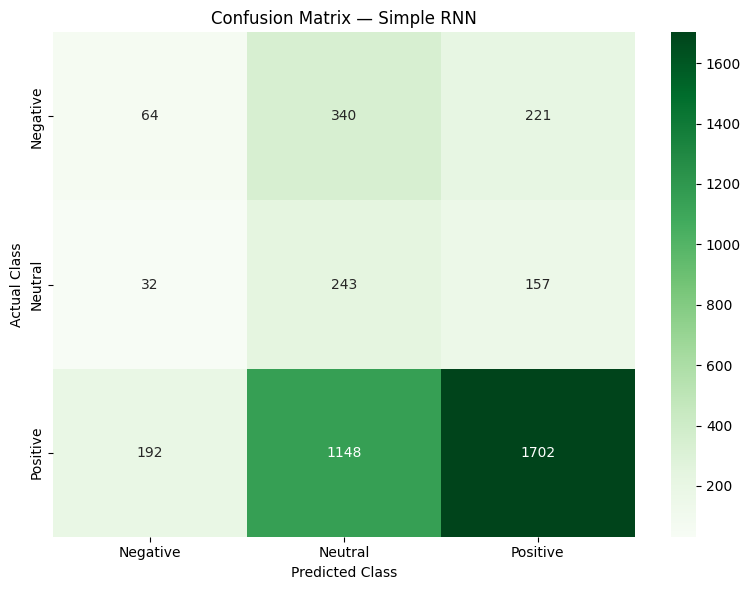

In [26]:
rnn_predictions, rnn_accuracy = evaluate_model(rnn_model, test_padded, test_labels, label="Simple RNN", cmap_name="Greens")

In [27]:
print(f"Baseline RNN — Test Accuracy: {rnn_accuracy:.4f}")

Baseline RNN — Test Accuracy: 0.4901


---
# Model 2 – Bidirectional LSTM

Unlike standard RNN units, LSTM cells incorporate three learnable gates — input, forget, and output — that regulate information flow and enable the retention of long-range dependencies, effectively addressing the vanishing gradient limitation.
Wrapping the LSTM in a **Bidirectional** layer causes each sequence to be processed in both left-to-right and right-to-left directions, granting the model awareness of downstream context at every position.
Dropout is applied after selected layers to reduce co-adaptation of neurons and improve generalisation.

In [50]:
bilstm_model = Sequential([
    Input(shape=(sequence_length,)),
    Embedding(vocabulary_size, 128),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(class_count, activation='softmax')
])

bilstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'] # Changed from 'eval_accuracy' to 'accuracy'
)
bilstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 189, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 189, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 189, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 792,579 (3.02 MB)

 Trainable params: 792,579 (3.02 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model 2 – Bidirectional LSTM

In [58]:
bilstm_t_start = time.time()

bilstm_history = bilstm_model.fit(
    train_padded, train_labels,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopper],
    class_weight=label_weights
)

bilstm_t_end = time.time()
bilstm_elapsed = bilstm_t_end - bilstm_t_start
print(f"Training time: {bilstm_elapsed:.2f} sec")

Epoch 1/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.4788 - loss: 1.0625 - val_accuracy: 0.7112 - val_loss: 1.1259
Epoch 2/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6477 - loss: 1.0307 - val_accuracy: 0.7295 - val_loss: 1.1020
Epoch 3/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.6576 - loss: 1.0020 - val_accuracy: 0.1552 - val_loss: 1.4133
Epoch 4/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7514 - loss: 0.9912 - val_accuracy: 0.7286 - val_loss: 1.1531
Epoch 5/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7559 - loss: 0.9755 - val_accuracy: 0.7356 - val_loss: 1.1799
Training time: 55.46 sec


## Model 2 – Training Curves

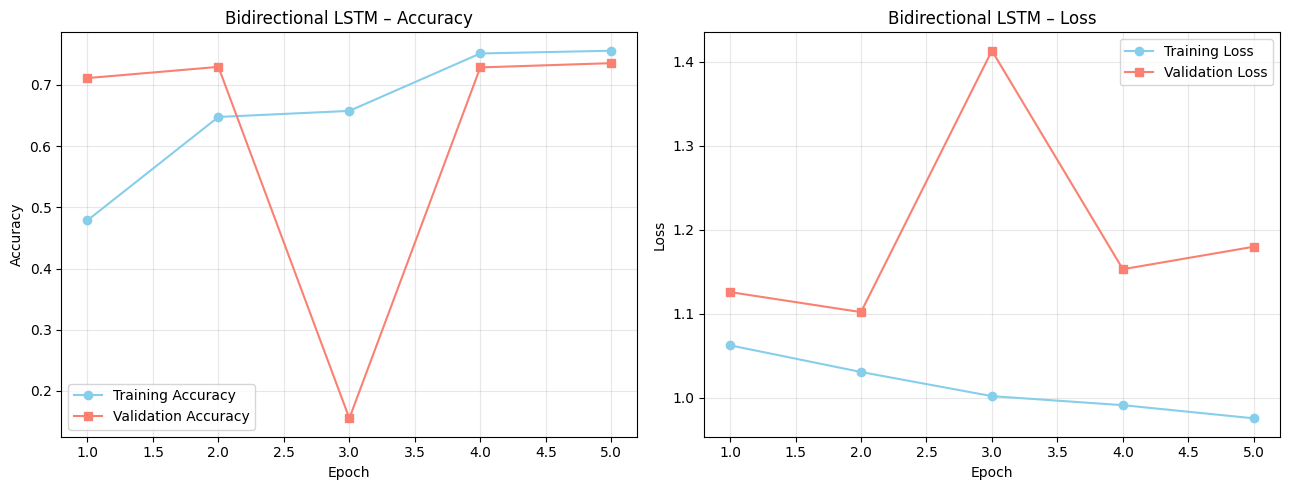

In [59]:
display_learning_curves(bilstm_history, title_prefix="Bidirectional LSTM")

## Evaluate Model 2 – Bidirectional LSTM

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step

  Classification Report — Bidirectional LSTM
              precision    recall  f1-score   support

    Negative       0.65      0.03      0.06       625
     Neutral       0.15      0.10      0.12       432
    Positive       0.76      0.94      0.84      3042

    accuracy                           0.71      4099
   macro avg       0.52      0.36      0.34      4099
weighted avg       0.68      0.71      0.64      4099



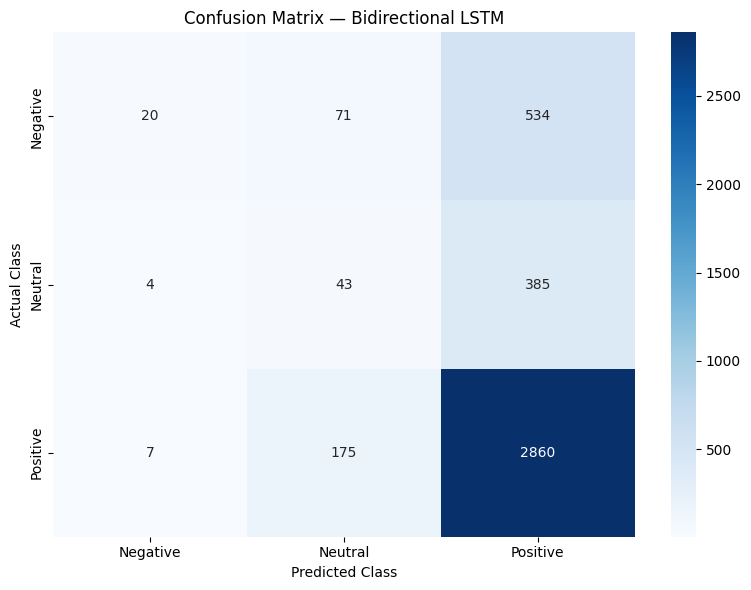

In [60]:
bilstm_predictions, bilstm_accuracy = evaluate_model(bilstm_model, test_padded, test_labels, label="Bidirectional LSTM", cmap_name="Blues")

In [61]:
print(f"BiLSTM — Test Accuracy: {bilstm_accuracy:.4f}")

BiLSTM — Test Accuracy: 0.7131


---# Model 3 – LSTM with Pretrained Word2Vec Embeddings

This variant replaces the randomly initialised embedding layer with vectors from **Word2Vec (word2vec-google-news-300)**, fetched via `gensim.downloader`.
The embedding layer is locked (`trainable=False`) so these pretrained representations remain unchanged during fine-tuning.

Leveraging large-corpus pretraining allows the model to draw on broad semantic relationships between freq_words — associations that would be difficult to learn reliably from a single-domain dataset of limited size.

### Install Gensim

In [33]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.2 MB/s eta 0:00:00


### Load Pretrained Word2Vec Vectors

In [34]:
import gensim.downloader as api

gensim_w2v       = api.load("word2vec-google-news-300")
w2v_embed_size = 300
print("Pretrained Word2Vec vectors successfully loaded.")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Pretrained Word2Vec vectors successfully loaded.


### Build the Embedding Matrix

Each entry in the Keras vocabulary is looked up in the gensim Word2Vec model. If a match is found, the corresponding 300-dimensional vector is inserted into the matrix row for that word index. Tokens with no Word2Vec entry retain a default zero vector.

In [62]:
pretrained_embed_matrix = np.zeros((vocabulary_size, w2v_embed_size))

vocab_hits, vocab_misses = 0, 0
for word, i in text_tokenizer.word_index.items():
    if i < vocabulary_size:
        if word in gensim_w2v:
            pretrained_embed_matrix[i] = gensim_w2v[word]
            vocab_hits += 1
        else:
            vocab_misses += 1

print(f"Vocabulary matches found : {vocab_hits}")
print(f"Vocabulary misses (zero-initialised): {vocab_misses}")

Vocabulary matches found : 4713
Vocabulary misses (zero-initialised): 286


## Define Model 3 – LSTM + Word2Vec

In [66]:
w2v_model_nn = Sequential([
    Input(shape=(sequence_length,)),
    Embedding(
        input_dim=vocabulary_size,
        output_dim=w2v_embed_size,
        weights=[pretrained_embed_matrix],
        trainable=False   # freeze pretrained weights
    ),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(class_count, activation='softmax')
])

w2v_model_nn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'] # Changed from 'eval_accuracy' to 'accuracy'
)
w2v_model_nn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 189, 300)       │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,595,619 (6.09 MB)

 Trainable params: 95,619 (373.51 KB)

 Non-trainable params: 1,500,000 (5.72 MB)

## Train Model 3 – LSTM + Word2Vec

In [68]:
w2v_t_start = time.time()

w2v_history = w2v_model_nn.fit(
    train_padded, train_labels,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopper],
    class_weight=label_weights
)

w2v_t_end = time.time()
w2v_elapsed = w2v_t_end - w2v_t_start
print(f"Training time: {w2v_elapsed:.2f} sec")

Epoch 1/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.3914 - loss: 1.0589 - val_accuracy: 0.1436 - val_loss: 1.2123
Epoch 2/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3456 - loss: 1.0579 - val_accuracy: 0.7514 - val_loss: 0.8529
Epoch 3/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4696 - loss: 1.0734 - val_accuracy: 0.7100 - val_loss: 1.0683
Epoch 4/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6970 - loss: 1.0322 - val_accuracy: 0.7530 - val_loss: 1.0308
Epoch 5/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5473 - loss: 1.0569 - val_accuracy: 0.7103 - val_loss: 1.0996
Epoch 6/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5132 - loss: 1.0397 - val_accuracy: 0.7280 - val_loss: 1.0785
Epoch 7/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6995 - loss: 1.0229 - val_accuracy: 0.7377 - val_loss: 1.0867
Training time: 41.04 sec


## Model 3 – Training Curves

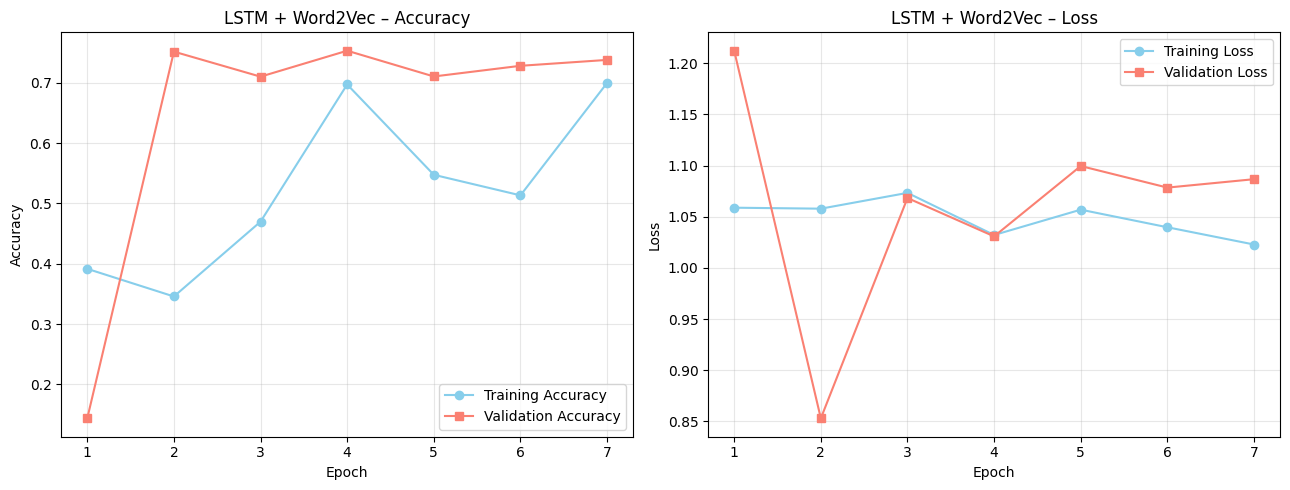

In [69]:
display_learning_curves(w2v_history, title_prefix="LSTM + Word2Vec")

## Evaluate Model 3 – LSTM + Word2Vec

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

  Classification Report — LSTM + Word2Vec
              precision    recall  f1-score   support

    Negative       0.46      0.72      0.56       625
     Neutral       0.15      0.06      0.09       432
    Positive       0.87      0.84      0.86      3042

    accuracy                           0.74      4099
   macro avg       0.49      0.54      0.50      4099
weighted avg       0.73      0.74      0.73      4099



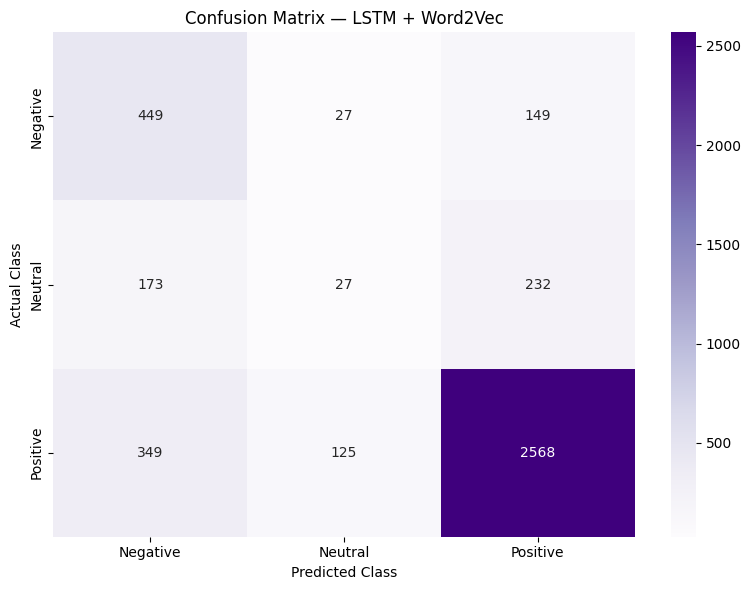

In [70]:
w2v_predictions, w2v_accuracy = evaluate_model(w2v_model_nn, test_padded, test_labels, label="LSTM + Word2Vec", cmap_name="Purples")

In [71]:
print(f"LSTM + Word2Vec — Test Accuracy: {w2v_accuracy:.4f}")

LSTM + Word2Vec — Test Accuracy: 0.7426


---
# Comparative Analysis

## All Models – Validation Curves on Same Axes

Overlaying the validation accuracy and loss trajectories of all three architectures onto shared axes allows direct comparison of convergence speed, stability, and final held-out performance across training epochs.

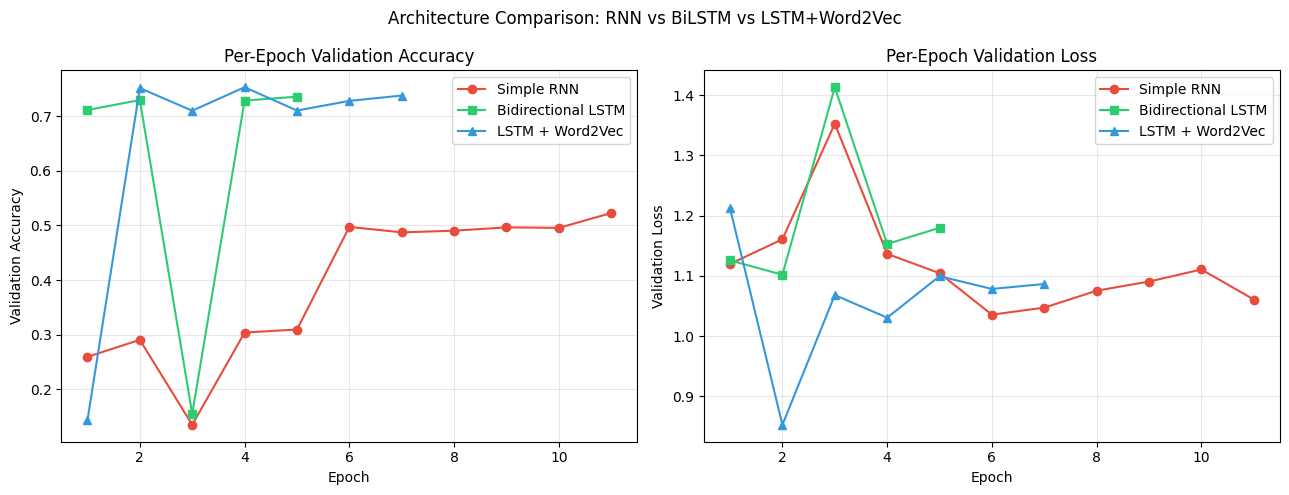

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

all_histories    = {
    "Simple RNN":         rnn_history,
    "Bidirectional LSTM": bilstm_history,
    "LSTM + Word2Vec":       w2v_history
}
plot_colors = ['#e74c3c', '#2ecc71', '#3498db'] # New colors for line graphs
markers     = ['o', 's', '^']

for (name, hist), color, marker in zip(all_histories.items(), plot_colors, markers):
    ep = range(1, len(hist.history['val_accuracy']) + 1)
    ax1.plot(ep, hist.history['val_accuracy'], label=name, color=color, marker=marker, linewidth=1.5)
    ax2.plot(ep, hist.history['val_loss'],     label=name, color=color, marker=marker, linewidth=1.5)

ax1.set_title("Per-Epoch Validation Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title("Per-Epoch Validation Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Architecture Comparison: RNN vs BiLSTM vs LSTM+Word2Vec", fontsize=12)
plt.tight_layout()
plt.show()

## Final Test Accuracy – Bar Chart

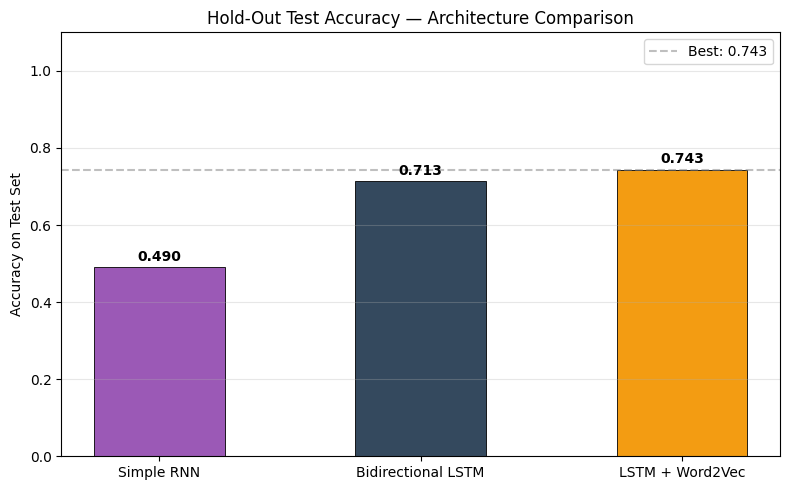

In [73]:
rnn_accuracy  = accuracy_score(test_labels, rnn_predictions)
bilstm_accuracy = accuracy_score(test_labels, bilstm_predictions)
w2v_accuracy  = accuracy_score(test_labels, w2v_predictions)

model_names = ["Simple RNN", "Bidirectional LSTM", "LSTM + Word2Vec"]
accuracy_scores         = [rnn_accuracy, bilstm_accuracy, w2v_accuracy]
bar_palette   = ['#9b59b6', '#34495e', '#f39c12'] # New palette for accuracy bar chart

fig, ax = plt.subplots(figsize=(8, 5))
bar_patches = ax.bar(model_names, accuracy_scores, color=bar_palette, edgecolor='black', linewidth=0.6, width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy on Test Set")
ax.set_title("Hold-Out Test Accuracy — Architecture Comparison")
ax.axhline(y=max(accuracy_scores), color='gray', linestyle='--', alpha=0.5, label=f"Best: {max(accuracy_scores):.3f}")
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bar_patches, accuracy_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{acc:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Summary Table

In [74]:
# Get test losses for all models
rnn_loss_score  = rnn_model.evaluate(test_padded, test_labels, verbose=0)[0]
bilstm_loss_score = bilstm_model.evaluate(test_padded, test_labels, verbose=0)[0]
w2v_loss_score  = w2v_model_nn.evaluate(test_padded, test_labels, verbose=0)[0]

print("\n" + "=" * 72)
print("               PERFORMANCE OVERVIEW — ALL MODELS")
print("=" * 72)
print(f"{'Architecture':<28} {'Test Acc':>10} {'Test Loss':>10} {'Duration (s)':>16}")
print("-" * 72)

results_table = [
    ("Simple RNN",         rnn_accuracy,  rnn_loss_score,  rnn_elapsed),
    ("Bidirectional LSTM", bilstm_accuracy, bilstm_loss_score, bilstm_elapsed),
    ("LSTM + GloVe",       w2v_accuracy,  w2v_loss_score,  w2v_elapsed),
]
for name, acc, loss, t in results_table:
    print(f"{name:<28} {acc:>10.4f} {loss:>10.4f} {t:>16.2f}")
print("=" * 72)

top_model = results_table[np.argmax([r[1] for r in results_table])][0]
print(f"\nTop-ranked model: {top_model}")


               PERFORMANCE OVERVIEW — ALL MODELS
Architecture                   Test Acc  Test Loss     Duration (s)
------------------------------------------------------------------------
Simple RNN                       0.4901     1.0376            85.68
Bidirectional LSTM               0.7131     1.1196            55.46
LSTM + GloVe                     0.7426     0.8628            41.04

Top-ranked model: LSTM + GloVe


---
# Error Analysis

Incorrectly classified examples from the top-performing model are examined to identify recurring patterns in the types of reviews the model struggles with, and to highlight potential sources of prediction error.

In [75]:
# Prediction Error Inspection — LSTM + Word2Vec (Best Model)
print("Misclassification Review — LSTM + Word2Vec (Best Model)\n")

mistake_indices = np.where(w2v_predictions != test_labels)[0]

print(f"Total incorrect predictions: {len(mistake_indices)} / {len(test_labels)}")
print(f"Overall error rate: {len(mistake_indices)/len(test_labels)*100:.2f}%\n")
print("--- Three Sample Prediction Errors ---\n")

for idx, err_i in enumerate(mistake_indices[:3]):
    print(f"Case {idx + 1}:")
    print(f"  Original review : {X_test.iloc[err_i][:200]}...")
    print(f"  True label: {SENTIMENT_CLASSES[test_labels[err_i]]}")
    print(f"  Predicted : {SENTIMENT_CLASSES[w2v_predictions[err_i]]}")
    print("-" * 60)

Misclassification Review — LSTM + Word2Vec (Best Model)

Total incorrect predictions: 1055 / 4099
Overall error rate: 25.74%

--- Three Sample Prediction Errors ---

Case 1:
  Original review : barcelona rock stayed hotel jazz girlfriend night end augustthe hotel excellent location carrer pelai close placa catalunya ramblas appreciate buzz city removed respite mayhem crowd caught airport bus...
  True label: Positive
  Predicted : Negative
------------------------------------------------------------
Case 2:
  Original review : ok hotel good location stayed night way beijing rawa island hotel service room ok location great shopping restaurant probably stay opinion nice star hotel...
  True label: Neutral
  Predicted : Positive
------------------------------------------------------------
Case 3:
  Original review : great service nice pool ok beach lovely ground small room stayed day night st th quick cab ride hotel line checkin requested king bed guaranteed offered double b club level fl

### Discussion – Possible Reasons for Errors

1. **Ambiguous or mixed-sentiment reviews** – A single review may commend certain aspects of the stay (e.g. location or cleanliness) while criticising others (e.g. service or noise). The model receives conflicting signals and tends to predict the predominant sentiment class.

2. **Sarcasm and implicit negativity** – Expressions such as *"Oh brilliant, the hot water was out again"* are semantically negative but contain surface-level positive vocabulary (`brilliant`). Without sarcasm-aware pretraining, RNN and LSTM models rarely detect this distinction.

3. **Sparse or very short reviews** – Extremely brief submissions (e.g. *"It was fine."*) leave little context for the model to work with. After stopword removal and lemmatisation, only one or two tokens may remain, making reliable sentiment inference difficult.

4. **Neutral class underrepresentation** – Ratings of exactly 3 stars (Neutral) constitute the smallest portion of the dataset. Although label weighting helps, the model may still conflate Neutral reviews with adjacent sentiment categories.

### Model Complexity vs. Performance

| Model | Parameters | Captures Long-Range | Pretrained Knowledge | Expected Accuracy |
|---|---|---|---|---|
| Simple RNN | Low | ✗ (vanishing gradient) | ✗ | Lowest |
| Bidirectional LSTM | Medium | ✓ | ✗ | Medium |
| LSTM + Word2Vec | Medium | ✓ | ✓ | Highest |

### Suggested Improvements

- Substitute the current embedding layer with richer pretrained representations such as 300-d Word2Vec, FastText, or a transformer encoder like BERT, which captures contextual meaning more effectively.
- After an initial warm-up phase, unfreeze the embedding layer in Model 3 (`trainable=True`) to allow domain-specific fine-tuning of the pretrained vectors.
- Expand the vocabulary ceiling beyond 5 000 tokens to reduce the number of out-of-vocabulary collisions.
- Address class imbalance in the Neutral category through data augmentation techniques such as back-translation or synonym substitution.
- Incorporate a self-attention mechanism on top of the LSTM outputs to allow the model to weight sentiment-bearing tokens more heavily when forming the final representation.


---
# GUI – Real-Time Prediction with Gradio

A lightweight interactive web application that allows anyone to submit a hotel review and receive an immediate sentiment classification from the trained Bidirectional LSTM.

**Prediction pipeline:**
1. The submitted text is cleaned and normalised using the same `prepare_text()` function applied during training.
2. The processed text is encoded into integer sequences and zero-padded to match `sequence_length`.
3. The Bidirectional LSTM performs a forward pass and returns a probability vector over the three sentiment classes.
4. The predicted class label and associated score_dict scores are presented within the Gradio interface.

In [46]:
!pip install gradio --quiet

In [76]:
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

emoji_label_map = {0: "Negative 😞", 1: "Neutral 😐", 2: "Positive 😊"}

def classify_review(user_input):
    """Clean and tokenise the input, run inference, and return the sentiment prediction with confidence scores."""
    if not user_input.strip():
        return "No input detected — please type a hotel review.", {}

    clean_input    = prepare_text(user_input)
    seq        = text_tokenizer.texts_to_sequences([clean_input])
    padded     = pad_sequences(seq, maxlen=sequence_length, padding='post')
    probs      = bilstm_model.predict(padded, verbose=0)[0]
    predicted_idx = int(np.argmax(probs))
    score_dict = {emoji_label_map[i]: float(round(probs[i], 4)) for i in range(3)}
    return emoji_label_map[predicted_idx], score_dict


gradio_app = gr.Interface(
    fn=classify_review,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Share your hotel experience here...",
        label="Your Review"
    ),
    outputs=[
        gr.Text(label="Sentiment Result"),
        gr.Label(label="Class Probabilities", num_top_classes=3)
    ],
    title="Hotel Review Sentiment Analyser",
    description=(
        "Enter a hotel review and the Bidirectional LSTM model will predict "
        "whether the sentiment is Positive, Neutral, or Negative."
    ),
    examples=[
        ["The room was spotless and the staff were incredibly helpful. Will definitely return!"],
        ["Check-in was okay, nothing special. Room was average for the price."],
        ["Terrible experience. Noisy, dirty room and rude reception staff."],
    ],
    flagging_mode="never"
)

gradio_app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d86ca0e463a3693d66.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
